In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import pickle
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
import keras
from keras import layers, Model
from keras.callbacks import LambdaCallback

# Nastavení memory growth — zabrání alokaci celé VRAM najednou
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU nalezeno: {gpus[0].name}")
else:
    print("GPU nenalezeno – trénink poběží na CPU.")


GPU nenalezeno – trénink poběží na CPU.


---
## Část 1 – Příprava a zpracování dat

In [24]:
CORPUS_FILE   = 'cs.txt'   # Cesta ke korpusu
VOCAB_SIZE    = 20_000         # Počet nejčastějších slov ve slovníku
CONTEXT_SIZE  = 2              # Okno kontextu (2 vlevo + 2 vpravo)
EMBED_DIM     = 100            # Dimenze embeddingů
BATCH_SIZE    = 512
EPOCHS        = 5
UNK_TOKEN     = '<UNK>'
MODEL_FILE    = 'cbow_model.keras'
VOCAB_FILE    = 'vocab.pkl'


In [ ]:
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    raw_text = f.read()

print(f'Načteno {len(raw_text):,} znaků.')


Načteno 37,655,506 znaků.


In [26]:
def tokenize(text):
    """Jednoduchá tokenizace: lowercase + extrakce slov (bez interpunkce)."""
    text = text.lower()
    tokens = re.findall(r'[a-záčďéěíňóřšťúůýž]+', text)
    return tokens

tokens = tokenize(raw_text)
print(f'Celkem tokenů: {len(tokens):,}')
print(f'Ukázka: {tokens[:20]}')


Celkem tokenů: 5,201,340
Ukázka: ['jan', 'tříska', 'listopadu', 'praha', 'září', 'praha', 'byl', 'česko', 'americký', 'herec', 'jeho', 'manželkou', 'byla', 'karla', 'chadimová', 'v', 'letech', 'vystudoval', 'herectví', 'na']


In [ ]:
# Slovník: VOCAB_SIZE - 1 nejčastějších slov + <UNK>
counter = Counter(tokens)
most_common = counter.most_common(VOCAB_SIZE - 1)

word2idx = {UNK_TOKEN: 0}
for word, _ in most_common:
    word2idx[word] = len(word2idx)
idx2word = {v: k for k, v in word2idx.items()}

print(f'Velikost slovníku: {len(word2idx):,}')
print(f'Top 10 slov: {most_common[:10]}')


Velikost slovníku: 20,000
Top 10 slov: [('a', 166767), ('v', 160790), ('na', 78895), ('se', 78136), ('je', 50300), ('s', 45733), ('z', 41243), ('roce', 34012), ('do', 30646), ('byl', 30118)]


In [28]:
# Převod tokenů na indexy (slova mimo slovník → <UNK>)
encoded = [word2idx.get(t, 0) for t in tokens]

unk_ratio = encoded.count(0) / len(encoded)
print(f'Podíl <UNK>: {unk_ratio:.2%}')


Podíl <UNK>: 22.18%


In [29]:
def build_training_data(encoded_tokens, context_size):
    """
    Vytvoří trénovací dvojice (kontexty, cílové slovo).
    Přeskočí okna, kde je cíl <UNK> (index 0).
    """
    contexts = []
    targets  = []
    n = len(encoded_tokens)
    for i in range(context_size, n - context_size):
        target = encoded_tokens[i]
        if target == 0:       # Přeskočit <UNK> jako cíl
            continue
        ctx = (
            encoded_tokens[i - context_size : i] +
            encoded_tokens[i + 1 : i + context_size + 1]
        )
        contexts.append(ctx)
        targets.append(target)
    return np.array(contexts, dtype=np.int32), np.array(targets, dtype=np.int32)

X, y = build_training_data(encoded, CONTEXT_SIZE)
print(f'Trénovacích dvojic: {len(X):,}')
print(f'Ukázka kontextu: {X[0]} → cíl: {y[0]} ({idx2word[y[0]]})')


Trénovacích dvojic: 4,047,505
Ukázka kontextu: [250   0 267  98] → cíl: 129 (listopadu)


---
## Část 3 – Trénování modelu

Implementace CBOW architektury pomocí Keras: Embedding vrstva → průměrování → Dense + softmax.

In [30]:
def build_cbow_model(vocab_size, embed_dim, context_size):
    inputs = keras.Input(shape=(2 * context_size,), name='context')
    # Embedding vrstva
    emb = layers.Embedding(vocab_size, embed_dim, name='embeddings')(inputs)
    # Průměrování embeddingů kontextových slov
    avg = layers.Lambda(lambda x: keras.ops.mean(x, axis=1), name='avg_pool')(emb)
    # Výstupní vrstva
    outputs = layers.Dense(vocab_size, activation='softmax', name='output')(avg)
    model = Model(inputs, outputs, name='CBOW')
    return model

model = build_cbow_model(VOCAB_SIZE, EMBED_DIM, CONTEXT_SIZE)
model.summary()


Model: "CBOW"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context (InputLayer)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embeddings (Embedding)          │ (None, 4, 100)         │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool (Lambda)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 20000)          │     2,020,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,020,000 (15.34 MB)

 Trainable params: 4,020,000 (15.34 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)


In [32]:
history = model.fit(
    X, y,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.05,
    verbose=1,
)


Epoch 1/5
7511/7511 ━━━━━━━━━━━━━━━━━━━━ 672s 89ms/step - accuracy: 0.1027 - loss: 7.3268 - val_accuracy: 0.1831 - val_loss: 6.4432
Epoch 2/5
7511/7511 ━━━━━━━━━━━━━━━━━━━━ 652s 87ms/step - accuracy: 0.1610 - loss: 6.3794 - val_accuracy: 0.2036 - val_loss: 6.0404
Epoch 3/5
7511/7511 ━━━━━━━━━━━━━━━━━━━━ 661s 88ms/step - accuracy: 0.1799 - loss: 5.9766 - val_accuracy: 0.2138 - val_loss: 5.8430
Epoch 4/5
7511/7511 ━━━━━━━━━━━━━━━━━━━━ 699s 93ms/step - accuracy: 0.1915 - loss: 5.7225 - val_accuracy: 0.2187 - val_loss: 5.7273
Epoch 5/5
7511/7511 ━━━━━━━━━━━━━━━━━━━━ 717s 95ms/step - accuracy: 0.2000 - loss: 5.5419 - val_accuracy: 0.2216 - val_loss: 5.6589


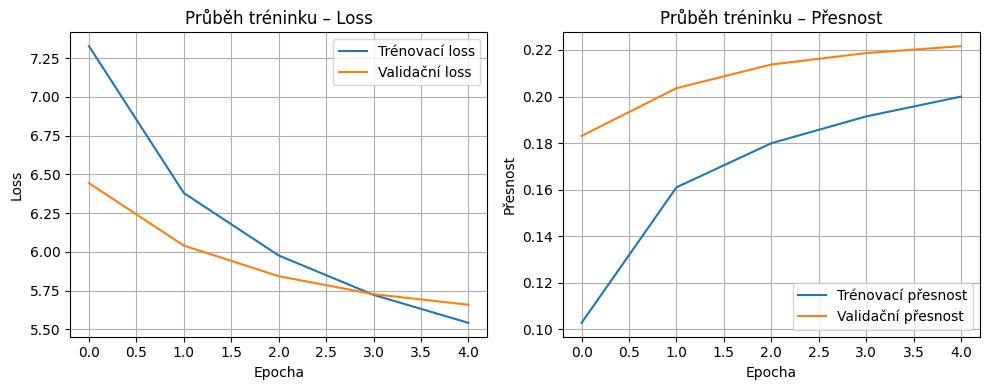

In [33]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Trénovací loss')
plt.plot(history.history['val_loss'], label='Validační loss')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.title('Průběh tréninku – Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Trénovací přesnost')
plt.plot(history.history['val_accuracy'], label='Validační přesnost')
plt.xlabel('Epocha'); plt.ylabel('Přesnost'); plt.title('Průběh tréninku – Přesnost')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


In [34]:
model.save(MODEL_FILE)
print(f'Model uložen jako {MODEL_FILE}')

# Extrakce embeddingů
embedding_matrix = model.get_layer('embeddings').get_weights()[0]
print(f'Rozměry embedding matice: {embedding_matrix.shape}')


Model uložen jako cbow_model.keras
Rozměry embedding matice: (20000, 100)


---
## Část 4 – Vyhodnocení modelu

In [35]:
def get_embedding(word):
    idx = word2idx.get(word, 0)
    return embedding_matrix[idx]

def nearest_neighbors(word, top_n=5):
    """Vrátí top_n nejbližších slov dle kosinové podobnosti."""
    if word not in word2idx:
        print(f'Slovo "{word}" není ve slovníku.')
        return []
    vec = get_embedding(word).reshape(1, -1)
    sims = cosine_similarity(vec, embedding_matrix)[0]
    sims[word2idx[word]] = -1  # Vyloučit samotné slovo
    top_idxs = np.argsort(sims)[::-1][:top_n]
    return [(idx2word[i], float(sims[i])) for i in top_idxs]


### 4.1 Nejbližší sousedé (kosinová podobnost)

In [36]:
test_words = ['pes', 'škola', 'krásný', 'město', 'věda']

for word in test_words:
    neighbors = nearest_neighbors(word, top_n=5)
    if neighbors:
        print(f'\nNejbližší sousedé slova "{word}":')
        for neighbor, sim in neighbors:
            print(f'  {neighbor:<20} {sim:.4f}')



Nejbližší sousedé slova "pes":
  klasický             0.6306
  čaj                  0.6140
  živý                 0.5870
  zelený               0.5687
  náš                  0.5489

Nejbližší sousedé slova "škola":
  knihovna             0.6740
  pec                  0.6611
  univerzita           0.6537
  soukromá             0.6415
  technická            0.6257

Nejbližší sousedé slova "krásný":
  kruhový              0.6935
  malý                 0.6899
  plochý               0.6829
  nahoře               0.6556
  modrý                0.6504

Nejbližší sousedé slova "město":
  obec                 0.6240
  nádraží              0.5702
  knížectví            0.5490
  městečko             0.5249
  městys               0.5220

Nejbližší sousedé slova "věda":
  ekonomická           0.6940
  kultura              0.6577
  odborná              0.6547
  forma                0.6474
  matematika           0.6431


### 4.2 Vizualizace embedding prostoru (t-SNE + PCA)

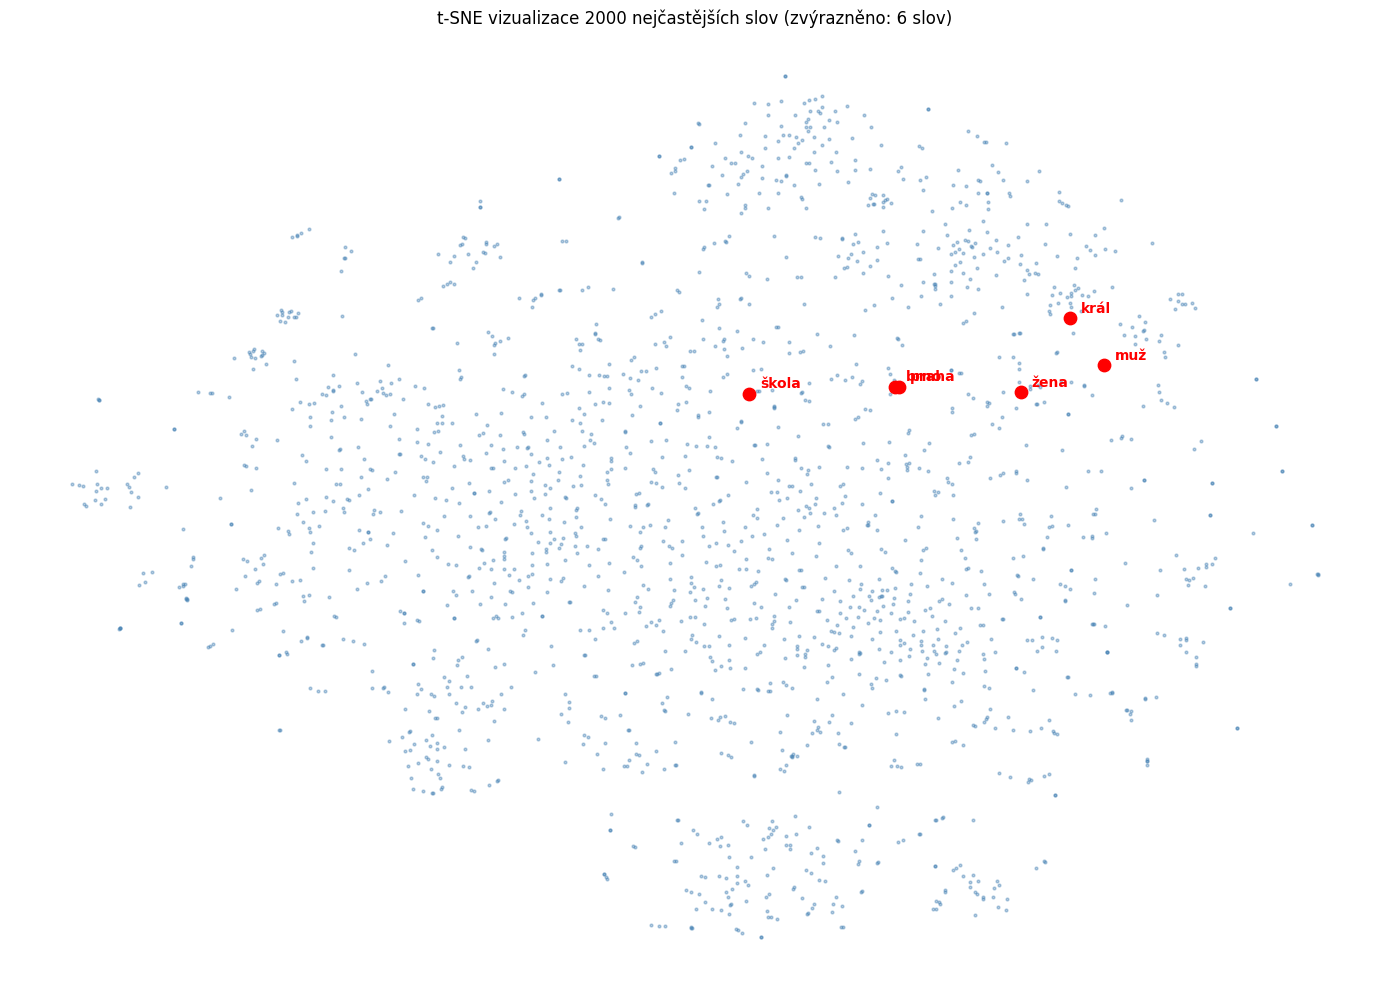

Zvýrazněná slova nalezena v top 2000: ['škola', 'muž', 'žena', 'král', 'praha', 'brno']


In [43]:
N_VIS = 2000
vis_words = [w for w, _ in most_common[:N_VIS]]
vis_idxs  = [word2idx[w] for w in vis_words]
vis_vecs  = embedding_matrix[vis_idxs]

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
vis_2d = tsne.fit_transform(vis_vecs)

# Slova pro zvýraznění (lowercase — tokenizace vše převádí)
highlight = ["pes", "kočka", "škola", "učitel", "krásný", "ošklivý",
             "muž", "žena", "král", "praha", "brno"]
highlight = [w for w in highlight if w in word2idx and w in vis_words]

fig, ax = plt.subplots(figsize=(14, 10))

# Šedé body pro nevybrané slova
mask = [i for i, w in enumerate(vis_words) if w not in highlight]
ax.scatter(vis_2d[mask, 0], vis_2d[mask, 1], s=4, alpha=0.4, color="steelblue")

# Zvýrazněné body
for word in highlight:
    idx_pos = vis_words.index(word)
    ax.scatter(vis_2d[idx_pos, 0], vis_2d[idx_pos, 1],
               s=80, color="red", zorder=5)
    ax.annotate(word, xy=(vis_2d[idx_pos, 0], vis_2d[idx_pos, 1]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=10, color="red", fontweight="bold")

if not highlight:
    ax.set_title(f"t-SNE vizualizace {N_VIS} nejčastějších slov (žádné ze zvýrazněných není v top {N_VIS})")
else:
    ax.set_title(f"t-SNE vizualizace {N_VIS} nejčastějších slov (zvýrazněno: {len(highlight)} slov)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Zvýrazněná slova nalezena v top {N_VIS}: {highlight}")


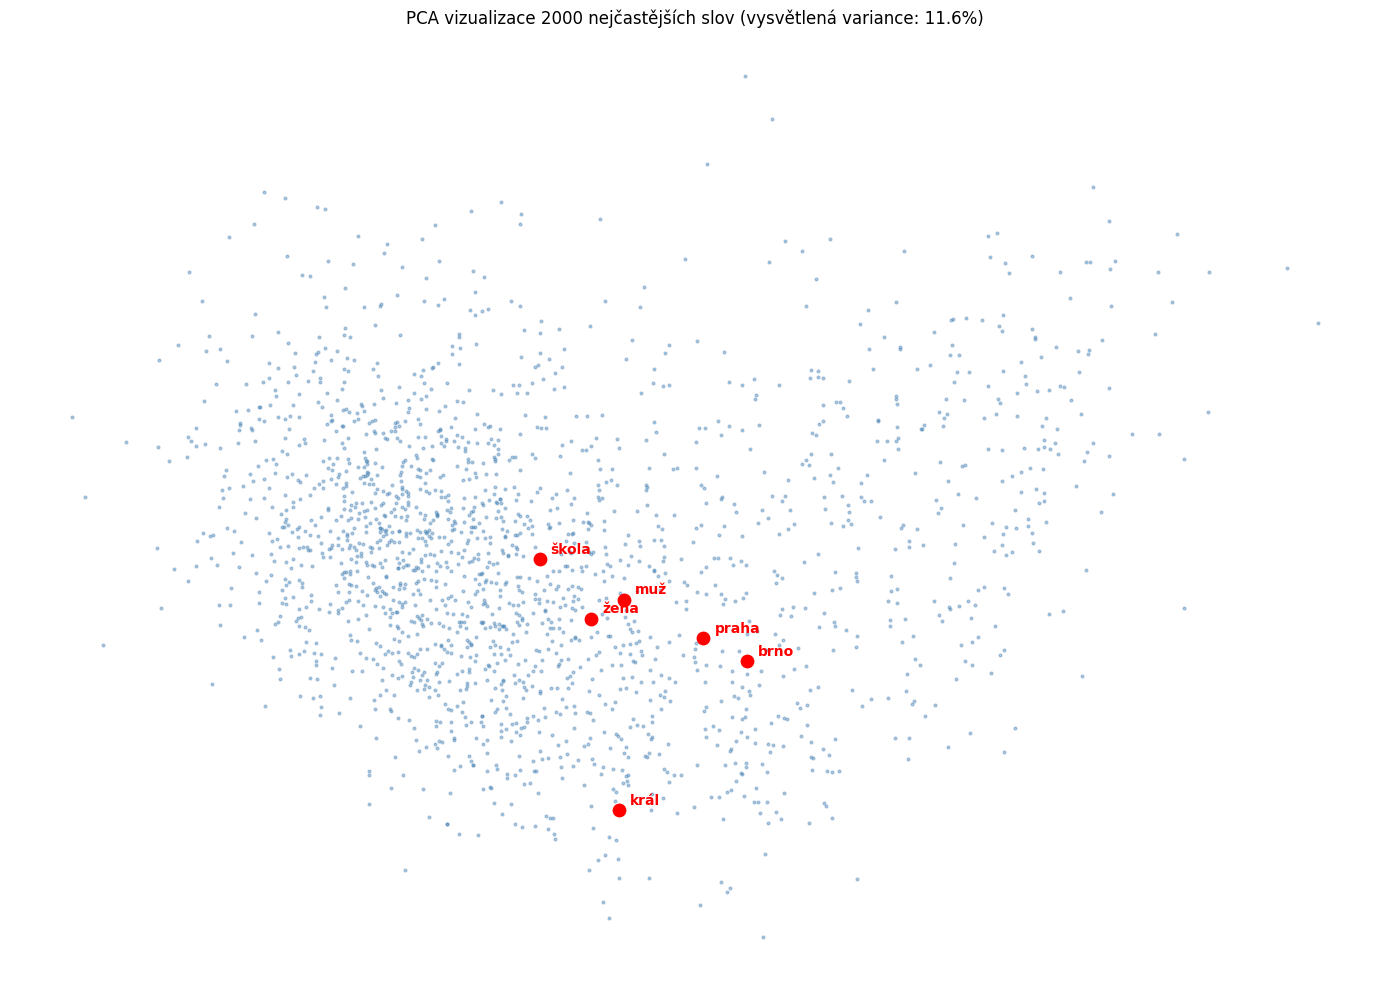

In [44]:
# PCA redukce
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(vis_vecs)

fig, ax = plt.subplots(figsize=(14, 10))

mask = [i for i, w in enumerate(vis_words) if w not in highlight]
ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=4, alpha=0.4, color="steelblue")

for word in highlight:
    idx_pos = vis_words.index(word)
    ax.scatter(pca_2d[idx_pos, 0], pca_2d[idx_pos, 1],
               s=80, color="red", zorder=5)
    ax.annotate(word, xy=(pca_2d[idx_pos, 0], pca_2d[idx_pos, 1]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=10, color="red", fontweight="bold")

ax.set_title(f"PCA vizualizace {N_VIS} nejčastějších slov "
             f"(vysvětlená variance: {pca.explained_variance_ratio_.sum():.1%})")
ax.axis("off")
plt.tight_layout()
plt.show()


### 4.3 Test analogií

Použijeme vektorovou operaci $v(b) - v(a) + v(c)$, která by měla přibližovat odpověď $d$ v analogii $a : b = c : d$.

In [45]:
def analogy(a, b, c, top_n=5, exclude_input=True):
    """
    Analogie: a : b = c : ?
    Hledá slova nejbližší vektoru v(b) - v(a) + v(c).
    """
    missing = [w for w in (a, b, c) if w not in word2idx]
    if missing:
        print(f'Slova mimo slovník: {missing}')
        return []

    query_vec = get_embedding(b) - get_embedding(a) + get_embedding(c)
    query_vec = query_vec.reshape(1, -1)
    sims = cosine_similarity(query_vec, embedding_matrix)[0]

    if exclude_input:
        for w in (a, b, c):
            sims[word2idx[w]] = -1

    top_idxs = np.argsort(sims)[::-1][:top_n]
    return [(idx2word[i], float(sims[i])) for i in top_idxs]

# Test analogií
tests = [
    ('muž', 'žena', 'král',   'očekáváme: královna'),
    ('praha', 'česko', 'paříž', 'očekáváme: francie'),
    ('pes', 'psi', 'kočka',   'očekáváme: kočky (plurál)'),
]

for a, b, c, hint in tests:
    results = analogy(a, b, c, top_n=5)
    if results:
        print(f'\nAnalogie: {a} : {b} = {c} : ? ({hint})')
        for word, sim in results:
            print(f'  {word:<20} {sim:.4f}')



Analogie: muž : žena = král : ? (očekáváme: královna)
  manželka             0.7069
  matka                0.6498
  poprava              0.6382
  císař                0.6119
  vláda                0.6106

Analogie: praha : česko = paříž : ? (očekáváme: francie)
  francie              0.6148
  maďarsko             0.5921
  švýcarsko            0.5859
  německo              0.5712
  dánsko               0.5410

Analogie: pes : psi = kočka : ? (očekáváme: kočky (plurál))
  algebry              0.5798
  semena               0.5507
  ionty                0.5466
  podmínka             0.5422
  komponenty           0.5362


**Hodnocení analogií:**

CBOW model s malým korpusem a krátkým tréninkem typicky nezachytí dokonale analogické vztahy — pro to by bylo potřeba trénovat na stovkách milionů slov. Pokud se správná odpověď objeví v top-5, jde o pozitivní signál. Kvalita závisí na velikosti korpusu, dimenzionalitě embeddingů a počtu epoch.

### 4.4 Biasy v embeddingu

Ověříme, zda embeddingy zachycují stereotypní asociace pomocí genderových analogií.

In [ ]:
# Genderový bias: žena - muž + profese = ?
bias_tests = [
    ('muž', 'žena', 'doktor', 'doktorka'),
    ('muž', 'žena', 'inženýr', 'inženýrka'),
    ('muž', 'žena', 'vědec', 'vědkyně'),
    ('žena', 'muž', 'zdravotní sestra', 'muž ve feminizované roli'),
]

print('=== GENDEROVÝ BIAS V EMBEDDINGÁCH ===\n')
for a, b, c, hint in bias_tests:
    results = analogy(a, b, c, top_n=5)
    if results:
        top_word = results[0][0] if results else 'N/A'
        print(f'Analogie: {a} : {b} = {c} : ? ({hint})')
        print(f'  Nejbližší výsledek: {top_word}')
        for word, sim in results:
            print(f'    {word:<25} {sim:.4f}')
        print()


=== GENDEROVÝ BIAS V EMBEDDINGÁCH ===

Analogie: muž : žena = doktor : ? (doktorka)
  Nejbližší výsledek: manželka
    manželka                  0.6827
    historička                0.6080
    manželky                  0.6027
    básnířka                  0.5884
    matka                     0.5710

Analogie: muž : žena = inženýr : ? (inženýrka)
  Nejbližší výsledek: básnířka
    básnířka                  0.6313
    manželka                  0.6210
    malířka                   0.6135
    kritička                  0.6043
    kurátorka                 0.6005

Analogie: muž : žena = vědec : ? (vědkyně)
  Nejbližší výsledek: kritička
    kritička                  0.6848
    básnířka                  0.6740
    aktivistka                0.6465
    pracovnice                0.6462
    spisovatelka              0.6291

Slova mimo slovník: ['zdravotní sestra']


**Vysvětlení genderového biasu:**

Pokud model pro analogii *muž : žena = doktor : ?* vrátí *doktorka* (femininum), jde o jazykově korektní odpověď. Pokud ale vrátí slova jako *sestra*, *zdravotnice* nebo jiné stereotypně ženské profese, jde o projev genderového biasu.